# Figure F - G

Recognition task performance and saccade angle and duration

/var/folders/6r/pj2ql3m51fv8_ycglzy0hnh40000gn/T/ipykernel_24245/1212726221.py:34: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.pointplot(


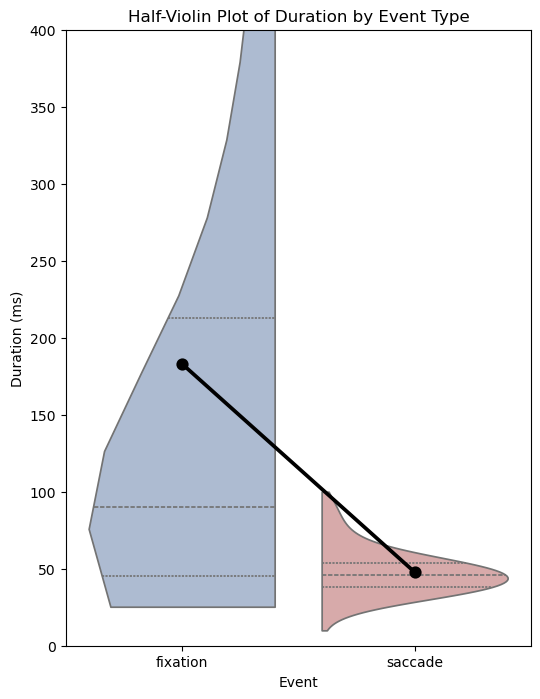

/var/folders/6r/pj2ql3m51fv8_ycglzy0hnh40000gn/T/ipykernel_24245/1212726221.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='condition', y='duration_ms', data=saccade_data, density_norm='width',bw_adjust=3,
/var/folders/6r/pj2ql3m51fv8_ycglzy0hnh40000gn/T/ipykernel_24245/1212726221.py:63: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.pointplot(x='condition', y='duration_ms', data=saccade_data,


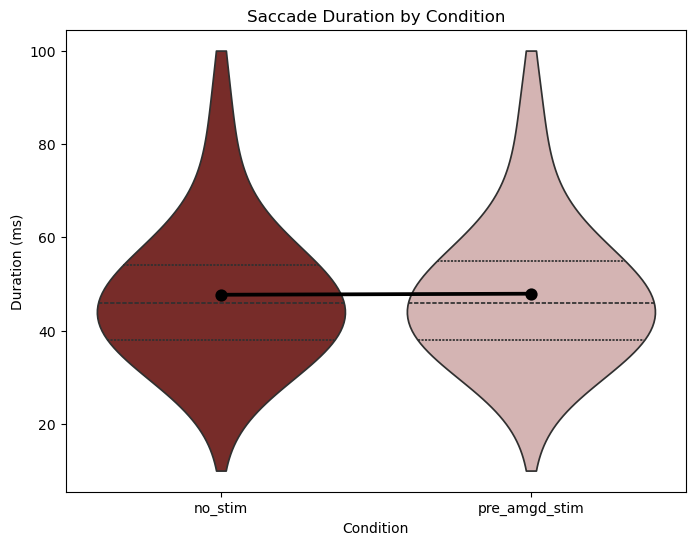

/var/folders/6r/pj2ql3m51fv8_ycglzy0hnh40000gn/T/ipykernel_24245/1212726221.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='condition', y='duration_ms', data=fixation_data, density_norm='width',bw_adjust=3,
/var/folders/6r/pj2ql3m51fv8_ycglzy0hnh40000gn/T/ipykernel_24245/1212726221.py:80: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.pointplot(x='condition', y='duration_ms', data=fixation_data,


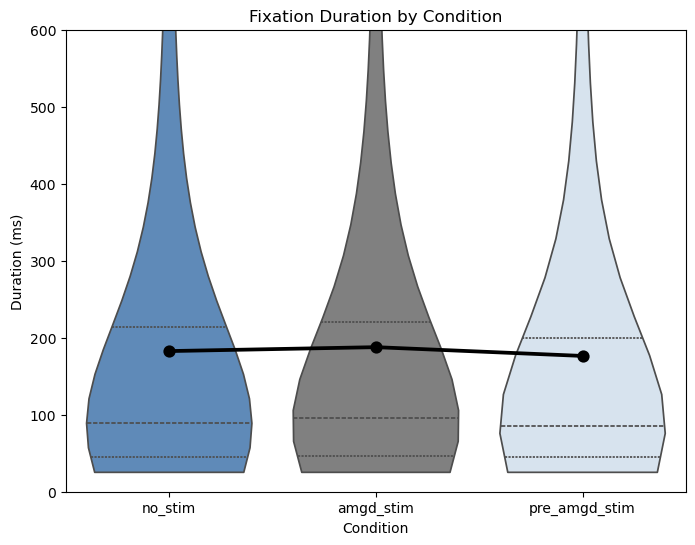

Effect Size (Cohen's d):
Saccade: d = -0.015
Fixation: d = 0.024
Sample sizes per event and condition:
      event      condition      n
0  fixation      amgd_stim  23352
1  fixation        no_stim  13978
2  fixation  pre_amgd_stim  14727
3   saccade        no_stim   3654
4   saccade  pre_amgd_stim   3684
Overall Duration Statistics by Event:
fixation: mean = 182.97 ms, std = 265.92 ms
saccade: mean = 47.79 ms, std = 14.93 ms

Saccade Duration Statistics by Condition:
no_stim: mean = 47.68 ms, std = 14.86 ms
pre_amgd_stim: mean = 47.90 ms, std = 15.00 ms

Fixation Duration Statistics by Condition:
amgd_stim: mean = 187.56 ms, std = 270.82 ms
no_stim: mean = 182.47 ms, std = 262.25 ms
pre_amgd_stim: mean = 176.16 ms, std = 261.38 ms


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

gaze_part1_filename = 'data/all_subj_task_gaze_properties.csv'
gaze_part2_filename = 'data/all_subj_task_gaze_properties_second_part.csv'
df1 = pd.read_csv(gaze_part1_filename)
df2 = pd.read_csv(gaze_part2_filename)

saccade_df = pd.concat([df1, df2], axis=0, ignore_index=True)
custom_palette = {"saccade": "#DEA3A2", "fixation": "#A7B9D7"}
saccade_df_filtered = saccade_df
saccade_df_filtered['duration_ms'] = saccade_df_filtered['duration'] * 1000

Q1 = saccade_df_filtered['duration_ms'].quantile(0.25)
Q3 = saccade_df_filtered['duration_ms'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

plot_data = saccade_df_filtered

plt.figure(figsize=(6, 8))
ax = plt.gca()

sns.violinplot(
    data=plot_data, density_norm='width',bw_adjust=3,
    x='event', y='duration_ms', hue='event',
    palette=custom_palette, split=True, inner='quart', cut=0, ax=ax, 
)

sns.pointplot(
    x='event', y='duration_ms', data=saccade_df_filtered,
    estimator=np.mean, ci=None, color="black", ax=ax
)

ax.set_xlabel("Event")
ax.set_ylabel("Duration (ms)")
ax.set_title("Half-Violin Plot of Duration by Event Type")
plt.ylim([0, 400])
plt.show()


## we separate saccade/fixation based on amgd_stim_flag and pre_stim_flag. 
# Get sub df and visualize them using violin plot, also calculate the effect size between conditions 
saccade_df_filtered['condition'] = np.where(
    saccade_df_filtered['amgd_stim_flag'] == 1, 'amgd_stim',
    np.where(saccade_df_filtered['pre_amgd_stim_flag'] == 1, 'pre_amgd_stim', 'no_stim')
)

saccade_data = saccade_df_filtered[saccade_df_filtered['event'] == 'saccade']
fixation_data = saccade_df_filtered[saccade_df_filtered['event'] == 'fixation']

custom_palette_conditions = {"pre_amgd_stim": "#DAAFAD", 
                             "no_stim": "#84201C"}

plt.figure(figsize=(8, 6))
ax1 = plt.gca()
sns.violinplot(x='condition', y='duration_ms', data=saccade_data, density_norm='width',bw_adjust=3,
               palette=custom_palette_conditions, inner='quart', cut=0)
sns.pointplot(x='condition', y='duration_ms', data=saccade_data,
              estimator=np.mean, ci=None, color='black', ax=ax1)
ax1.set_title("Saccade Duration by Condition")
ax1.set_xlabel("Condition")
ax1.set_ylabel("Duration (ms)")

plt.show()

custom_palette_conditions = {"pre_amgd_stim": "#D3E3F2", 
                             "no_stim": "#508AC7",
                            "amgd_stim": '#808080'}

# --- Create Violin Plot for Saccade Events ---
plt.figure(figsize=(8, 6))
ax1 = plt.gca()
sns.violinplot(x='condition', y='duration_ms', data=fixation_data, density_norm='width',bw_adjust=3,
               palette=custom_palette_conditions, inner='quart', cut=0)
sns.pointplot(x='condition', y='duration_ms', data=fixation_data,
              estimator=np.mean, ci=None, color='black', ax=ax1)
ax1.set_title("Fixation Duration by Condition")
ax1.set_xlabel("Condition")
ax1.set_ylabel("Duration (ms)")
plt.ylim([0, 600])

plt.show()

## calculate differences: 
def cohen_d(x, y):

    n1, n2 = len(x), len(y)
    mean1, mean2 = np.mean(x), np.mean(y)
    var1, var2 = np.var(x, ddof=1), np.var(y, ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (mean1 - mean2) / pooled_std if pooled_std > 0 else np.nan


saccade_no_stim = saccade_data[saccade_data['condition'] == 'no_stim']['duration_ms']
saccade_pre_stim = saccade_data[saccade_data['condition'] == 'pre_amgd_stim']['duration_ms']

fixation_no_stim = fixation_data[fixation_data['condition'] == 'no_stim']['duration_ms']
fixation_pre_stim = fixation_data[fixation_data['condition'] == 'pre_amgd_stim']['duration_ms']

d_saccade = cohen_d(saccade_no_stim, saccade_pre_stim)
d_fixation = cohen_d(fixation_no_stim, fixation_pre_stim)

print("Effect Size (Cohen's d):")
print(f"Saccade: d = {d_saccade:.3f}")
print(f"Fixation: d = {d_fixation:.3f}")

sample_sizes = saccade_df_filtered.groupby(['event', 'condition']).size().reset_index(name='n')
print("Sample sizes per event and condition:")
print(sample_sizes)

print("Overall Duration Statistics by Event:")
for event, group in saccade_df_filtered.groupby('event'):
    mean_duration = group['duration_ms'].mean()
    std_duration = group['duration_ms'].std()
    print(f"{event}: mean = {mean_duration:.2f} ms, std = {std_duration:.2f} ms")

print("\nSaccade Duration Statistics by Condition:")
for condition, group in saccade_data.groupby('condition'):
    mean_duration = group['duration_ms'].mean()
    std_duration = group['duration_ms'].std()
    print(f"{condition}: mean = {mean_duration:.2f} ms, std = {std_duration:.2f} ms")

print("\nFixation Duration Statistics by Condition:")
for condition, group in fixation_data.groupby('condition'):
    mean_duration = group['duration_ms'].mean()
    std_duration = group['duration_ms'].std()
    print(f"{condition}: mean = {mean_duration:.2f} ms, std = {std_duration:.2f} ms")

## saccade angle

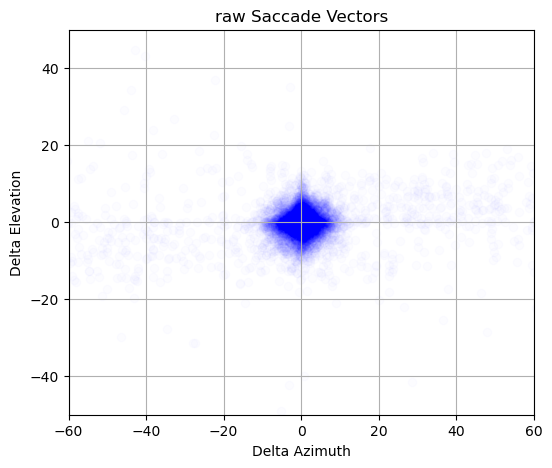

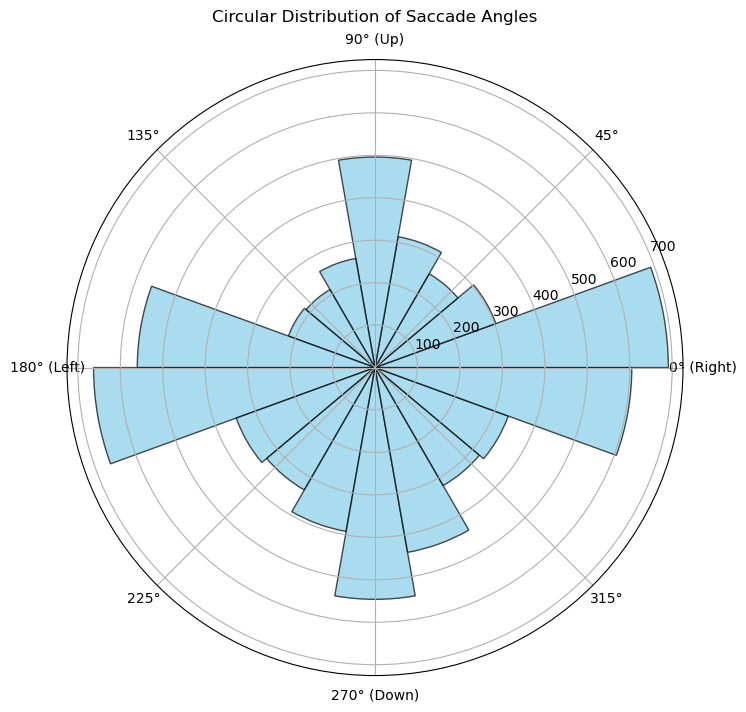

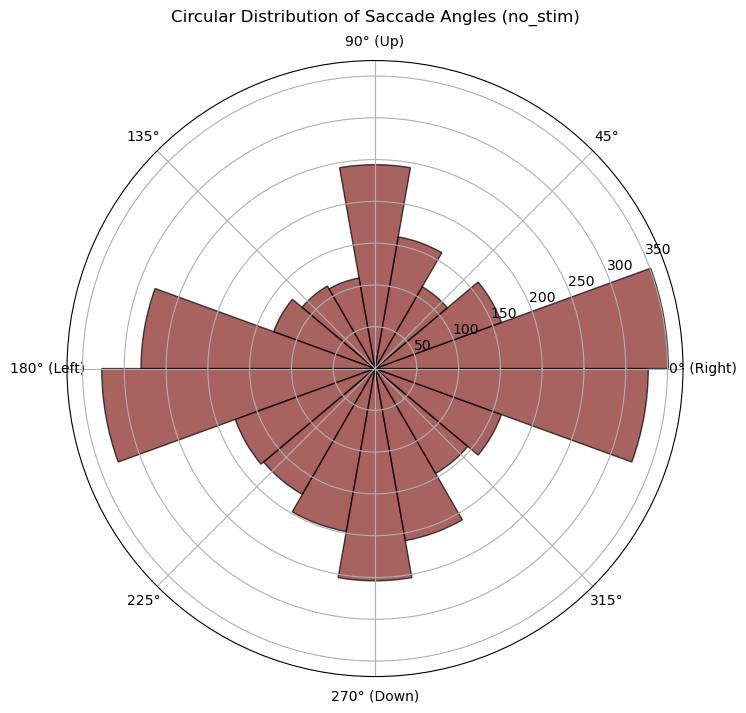

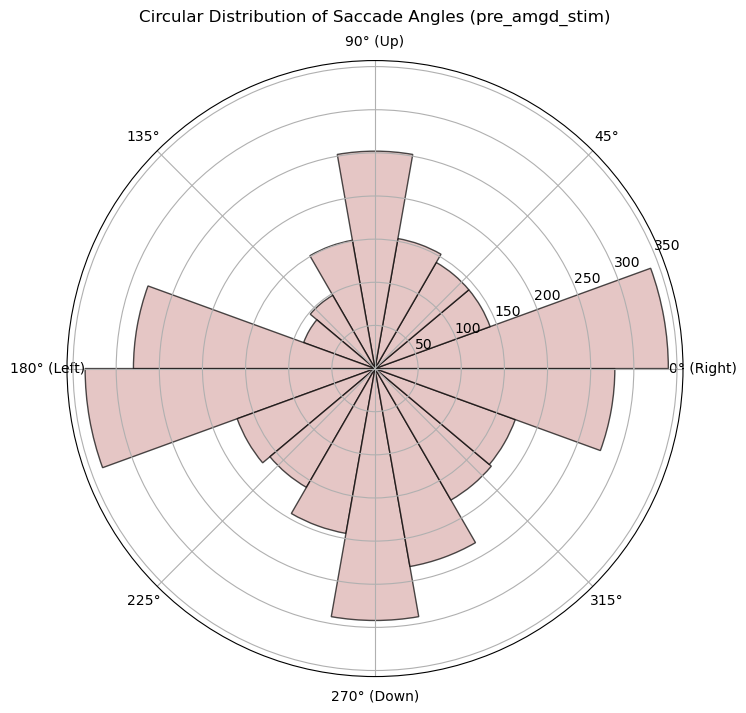

Percentage results for all data:
   Group  Percentage  Count  N_total
0  Right   17.772902   1296     7292
1   Left   16.771805   1223     7292
2     Up   11.341196    827     7292
3   Down   13.631377    994     7292
Percentage results by condition and group:
       Condition  Group  Percentage  Count  N_total
0        no_stim  Right   18.651994    678     3635
1        no_stim   Left   16.698762    607     3635
2        no_stim     Up   11.141678    405     3635
3        no_stim   Down   12.984869    472     3635
4  pre_amgd_stim  Right   16.899098    618     3657
5  pre_amgd_stim   Left   16.844408    616     3657
6  pre_amgd_stim     Up   11.539513    422     3657
7  pre_amgd_stim   Down   14.273995    522     3657


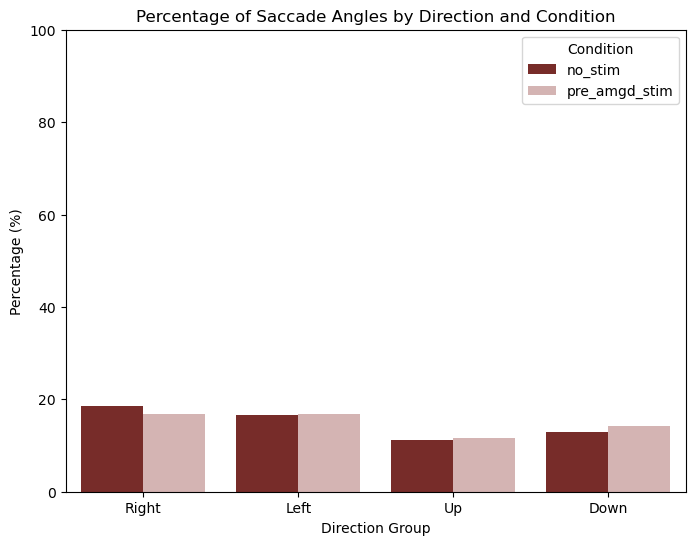

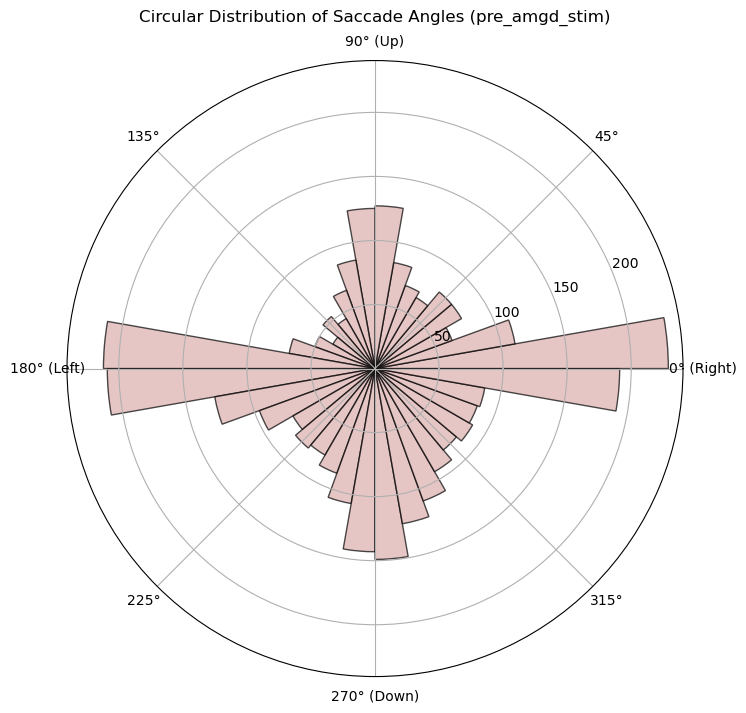

In [4]:
saccade_events = saccade_df_filtered[saccade_df_filtered['event'] == 'saccade'].copy()

saccade_events['delta_azimuth'] = saccade_events['azimuth_after'] - saccade_events['azimuth_before']
saccade_events['delta_elevation'] = saccade_events['elevation_after'] - saccade_events['elevation_before']



plt.figure(figsize=(6,5))
plt.scatter(saccade_events['delta_azimuth'], saccade_events['delta_elevation'], color='blue', alpha=0.01)
plt.title("raw Saccade Vectors")
plt.xlabel("Delta Azimuth")
plt.ylabel("Delta Elevation")
plt.xlim([-60,60])
plt.ylim([-50,50])
plt.grid(True)

plt.show()

## do saccade angle in radians
saccade_events['angle_rad'] = np.arctan2(saccade_events['delta_elevation'], saccade_events['delta_azimuth'])
saccade_events['angle_deg'] = np.degrees(saccade_events['angle_rad'])

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

num_bins = 18
bins = np.linspace(-np.pi, np.pi, num_bins + 1)
counts, bin_edges = np.histogram(saccade_events['angle_rad'], bins=bins)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

bars = ax.bar(bin_centers, counts, width=(2*np.pi)/num_bins, bottom=0.0, color="skyblue", edgecolor="black", alpha=0.7)
tick_locations = np.radians([0, 45, 90, 135, 180, 225, 270, 315])
tick_labels = ["0° (Right)", "45°", "90° (Up)", "135°", "180° (Left)", "225°", "270° (Down)", "315°"]
ax.set_xticks(tick_locations)
ax.set_xticklabels(tick_labels)

ax.set_title("Circular Distribution of Saccade Angles", va='bottom')

plt.show()


conditions_of_interest = ['no_stim', 'pre_amgd_stim']
saccade_two = saccade_df_filtered[
    (saccade_df_filtered['event'] == 'saccade') &
    (saccade_df_filtered['condition'].isin(conditions_of_interest))
].copy()

custom_palette_conditions = {"pre_amgd_stim": "#DAAFAD", "no_stim": "#84201C"}

saccade_two['delta_azimuth'] = saccade_two['azimuth_after'] - saccade_two['azimuth_before']
saccade_two['delta_elevation'] = saccade_two['elevation_after'] - saccade_two['elevation_before']

# fig, axes = plt.subplots(2, 2, figsize=(14, 12), sharex=True, sharey=True)


# for i, cond in enumerate(conditions_of_interest):
#     subset = saccade_two[saccade_two['condition'] == cond]
    
#     # Top row: 2D Kernel Density Estimate (KDE) plot
#     ax_kde = axes[0, i]
#     sns.kdeplot(
#         data=subset,
#         x="delta_azimuth", y="delta_elevation",
#         cmap="Reds", fill=True, thresh=0.11, levels=50,
#         ax=ax_kde
#     )
#     ax_kde.set_title(f"2D KDE of Saccade Vectors: {cond}")
#     ax_kde.set_xlabel("Δ Azimuth")
#     ax_kde.set_ylabel("Δ Elevation")
    
#     # Bottom row: Scatter plot of raw saccade vectors
#     ax_scatter = axes[1, i]
#     ax_scatter.scatter(
#         subset['delta_azimuth'], subset['delta_elevation'],
#         color='blue', alpha=0.01
#     )
#     ax_scatter.set_title(f"Raw Saccade Vectors: {cond}")
#     ax_scatter.set_xlabel("Δ Azimuth")
#     ax_scatter.set_ylabel("Δ Elevation")
#     ax_scatter.set_xlim([-60, 60])
#     ax_scatter.set_ylim([-50, 50])
#     ax_scatter.grid(True)

# plt.tight_layout()

# plt.show()


saccade_two['angle_rad'] = np.arctan2(saccade_two['delta_elevation'], saccade_two['delta_azimuth'])
saccade_two['angle_deg'] = np.degrees(saccade_two['angle_rad'])

for cond in conditions_of_interest:
    subset = saccade_two[saccade_two['condition'] == cond]
    plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, polar=True)
    num_bins = 18  # e.g., 36 bins (10° each)
    bins = np.linspace(-np.pi, np.pi, num_bins + 1)
    counts, bin_edges = np.histogram(subset['angle_rad'], bins=bins)
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    
    ax.bar(bin_centers, counts, width=(2 * np.pi) / num_bins, bottom=0.0,
           color=custom_palette_conditions[cond], edgecolor="black", alpha=0.7)
    
    # Set custom tick labels (0° is rightward/east, 90° upward/north, etc.)
    tick_locations = np.radians([0, 45, 90, 135, 180, 225, 270, 315])
    tick_labels = ["0° (Right)", "45°", "90° (Up)", "135°", "180° (Left)", "225°", "270° (Down)", "315°"]
    ax.set_xticks(tick_locations)
    ax.set_xticklabels(tick_labels)
    ax.set_title(f"Circular Distribution of Saccade Angles ({cond})", va='bottom')

    plt.show()

saccade_two = saccade_two.dropna(subset=['angle_deg']).copy()

saccade_two['angle_deg_mod'] = saccade_two['angle_deg'] % 360

def percentage_in_group(df, lower, upper):
    """Compute percentage of trials with angle between lower and upper (inclusive)."""
    n_total = len(df)
    if n_total == 0:
        return np.nan, 0
    count = ((df['angle_deg_mod'] >= lower) & (df['angle_deg_mod'] <= upper)).sum()
    return 100 * count / n_total, count

def percentage_group1(df):
    """For 'Right' group: angles in [340, 360] OR [0, 20]."""
    n_total = len(df)
    if n_total == 0:
        return np.nan, 0
    count = (((df['angle_deg_mod'] >= 340) & (df['angle_deg_mod'] <= 360)) |
             ((df['angle_deg_mod'] >= 0) & (df['angle_deg_mod'] <= 20))).sum()
    return 100 * count / n_total, count

groups = {
    'Right': percentage_group1,                      # Group 1: Right
    'Left': lambda df: percentage_in_group(df, 160, 200),  # Group 2: Left
    'Up': lambda df: percentage_in_group(df, 70, 110),     # Group 3: Up
    'Down': lambda df: percentage_in_group(df, 250, 290)   # Group 4: Down
}

overall_results = []
for group_name, func in groups.items():
    perc, count = func(saccade_two)
    overall_results.append({
         'Group': group_name,
         'Percentage': perc,
         'Count': count,
         'N_total': len(saccade_two)
    })

overall_results_df = pd.DataFrame(overall_results)
print("Percentage results for all data:")
print(overall_results_df)

results = []
for cond in conditions_of_interest:
    df_cond = saccade_two[saccade_two['condition'] == cond]
    for group_name, func in groups.items():
        perc, count = func(df_cond)
        results.append({
            'Condition': cond,
            'Group': group_name,
            'Percentage': perc,
            'Count': count,
            'N_total': len(df_cond)
        })

results_df = pd.DataFrame(results)
print("Percentage results by condition and group:")
print(results_df)

# ---------------------
# Bar plot of percentages
# ---------------------
plt.figure(figsize=(8, 6))
sns.barplot(data=results_df, x='Group', y='Percentage', hue='Condition', palette=custom_palette_conditions)
plt.title("Percentage of Saccade Angles by Direction and Condition")
plt.ylabel("Percentage (%)")
plt.xlabel("Direction Group")
plt.ylim(0, 100)

plt.show()


import pycircstat
no_stim_angles = saccade_two[saccade_two['condition'] == 'no_stim']['angle_rad'].dropna().values
pre_stim_angles = saccade_two[saccade_two['condition'] == 'pre_amgd_stim']['angle_rad'].dropna().values

# Perform the Watson–Williams test using pycircstat
# print(pycircstat.watson_williams(no_stim_angles, pre_stim_angles))

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)
num_bins = 36  # e.g., 36 bins (10° each)
bins = np.linspace(-np.pi, np.pi, num_bins + 1)
counts, bin_edges = np.histogram(subset['angle_rad'], bins=bins)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

ax.bar(bin_centers, counts, width=(2 * np.pi) / num_bins, bottom=0.0,
       color=custom_palette_conditions[cond], edgecolor="black", alpha=0.7)

# Set custom tick labels (0° is rightward/east, 90° upward/north, etc.)
tick_locations = np.radians([0, 45, 90, 135, 180, 225, 270, 315])
tick_labels = ["0° (Right)", "45°", "90° (Up)", "135°", "180° (Left)", "225°", "270° (Down)", "315°"]
ax.set_xticks(tick_locations)
ax.set_xticklabels(tick_labels)
ax.set_title(f"Circular Distribution of Saccade Angles ({cond})", va='bottom')

plt.show()

## Figure F 
task performance

/var/folders/6r/pj2ql3m51fv8_ycglzy0hnh40000gn/T/ipykernel_24245/1175268805.py:44: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(y='correct_recall_rate', data=agg_stats,


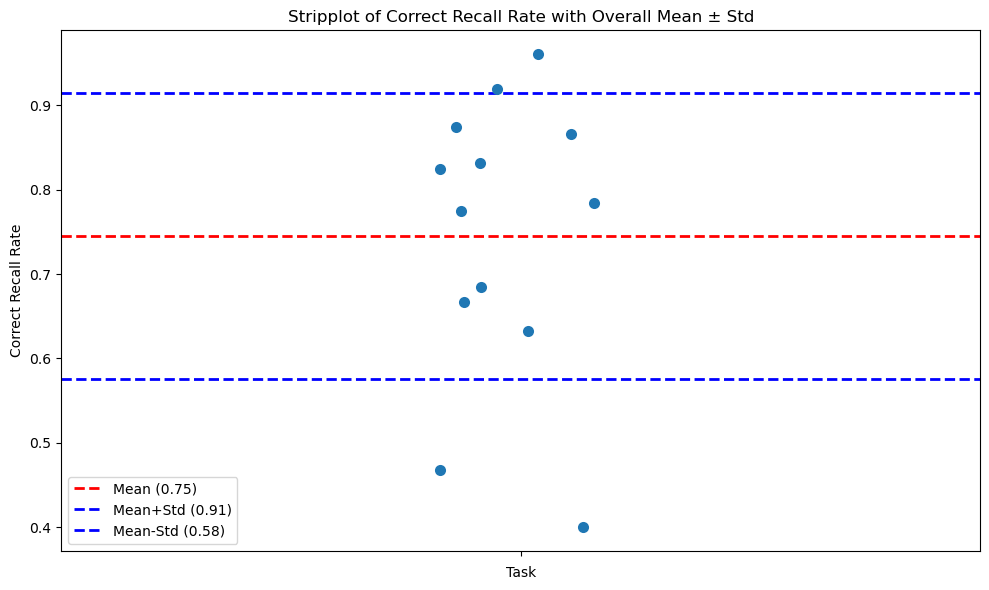

In [6]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



gaze_part1_filename = 'data/all_subj_task_gaze_properties_final.csv'
saccade_df = pd.read_csv(gaze_part1_filename)

saccade_df = saccade_df[~np.isnan(saccade_df['azimuth_before'])]
records = []

merged_trials = saccade_df.groupby(['subj', 'task', 'session', 'trial'], as_index=False)\
                          .agg({'remember_condition': 'first'})
# 2. For each trial, mark whether it was "tested" (i.e. not unknown) and whether it was correctly recalled.
merged_trials['tested'] = merged_trials['remember_condition'] != 'unknown'
merged_trials['correct'] = merged_trials['remember_condition'] == 'remember'

agg_stats = merged_trials.groupby(['subj', 'task']).agg(
    num_session = ('session', 'nunique'),
    num_trials = ('trial', 'count'),
    Encoding_Tested_Trials = ('tested', 'sum'),
    Encoding_Untested_Trials = ('tested', lambda x: (~x).sum()),
    Encoding_Correctly_Recalled = ('correct', 'sum'),
).reset_index()

agg_stats['Encoding_Total_Trials'] = agg_stats['num_trials']
agg_stats['Encoding_Incorrectly_Recalled'] = agg_stats['Encoding_Tested_Trials'] - agg_stats['Encoding_Correctly_Recalled']


agg_stats['correct_recall_rate'] = agg_stats['Encoding_Correctly_Recalled'] / agg_stats['Encoding_Tested_Trials']

agg_stats = agg_stats[['subj', 'task', 'num_session', 'num_trials', 'Encoding_Total_Trials',
                       'Encoding_Tested_Trials', 'Encoding_Untested_Trials',
                       'Encoding_Correctly_Recalled', 'Encoding_Incorrectly_Recalled', 'correct_recall_rate']]

# print("Aggregated Subject-Task Statistics:")
# print(agg_stats)


plt.figure(figsize=(10, 6))
sns.stripplot(y='correct_recall_rate', data=agg_stats,
              size=8, edgecolor='gray')

overall_mean = agg_stats['correct_recall_rate'].mean()
overall_std = agg_stats['correct_recall_rate'].std()

plt.axhline(overall_mean, color='red', linestyle='--', linewidth=2, label=f'Mean ({overall_mean:.2f})')
plt.axhline(overall_mean + overall_std, color='blue', linestyle='--', linewidth=2,
            label=f'Mean+Std ({(overall_mean+overall_std):.2f})')
plt.axhline(overall_mean - overall_std, color='blue', linestyle='--', linewidth=2,
            label=f'Mean-Std ({(overall_mean-overall_std):.2f})')

plt.legend()
plt.title('Stripplot of Correct Recall Rate with Overall Mean ± Std')
plt.xlabel('Task')
plt.ylabel('Correct Recall Rate')
plt.tight_layout()

plt.show()
